In [2]:
# Create global plots for seasons DJF, MAM, JJA, SON
# Do this for rainfall, spec humid, pot temp

In [3]:
import cartopy.crs as ccrs
import intake
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import easygems.healpix as egh

ERROR 1: PROJ: proj_create_from_database: Open of /home/users/rwjones/.conda/envs/hk26_env/share/proj failed


In [4]:
from utils import hp_mods, plot_all_fields

In [5]:
# Filter out annoying warning.
import warnings
warnings.filterwarnings("ignore", message=".*The return type of `Dataset.dims` will be changed.*", category=FutureWarning)

In [6]:
# Open catalog and print hk26 available models.
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']
# Use online if not on JASMIN.
# cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['online']
print('\n'.join([k for k in cat if k.endswith('_hk26')]))

um_Africa_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_Africa_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_CTC_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_CTC_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_SAmer_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_SAmer_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_SEA_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_SEA_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_glm_n1280_CoMA9_hk26
um_glm_n1280_GAL9_v2_hk26
um_glm_n2560_CoMA9_hk26
um_glm_n2560_RAL3p3_tuned_hk26


In [7]:
# Load models.
RALsim = 'um_glm_n2560_RAL3p3_tuned_hk26'
RALsim_cat = cat[RALsim]

GALsim = 'um_glm_n1280_GAL9_v2_hk26'
GALsim_cat = cat[GALsim]

COMA1sim = 'um_glm_n1280_CoMA9_hk26'
COMA1sim_cat = cat[COMA1sim]

COMA2sim = 'um_glm_n2560_CoMA9_hk26'
COMA2sim_cat = cat[COMA2sim]

In [8]:
# Open the 1hr datasets
GAL1h = GALsim_cat(zoom=5, time='PT1H').to_dask().pipe(hp_mods)
RAL1h = RALsim_cat(zoom=5, time='PT1H').to_dask().pipe(hp_mods)
COMA1_1h = COMA1sim_cat(zoom=5, time='PT1H').to_dask().pipe(hp_mods)
COMA2_1h = COMA2sim_cat(zoom=5, time='PT1H').to_dask().pipe(hp_mods)

In [9]:
# # Open a 1h (2D) and 3h (3D) dataset.
# ds1h = GALsim_cat(zoom=5, time='PT1H').to_dask().pipe(hp_mods)
# ds3h = GALsim_cat(zoom=5, time='PT3H').to_dask().pipe(hp_mods)

In [11]:
# Look at some data.
GAL1h

<xarray.Dataset> Size: 14GB
Dimensions:  (time: 9745, cell: 12288, depth: 4)
Coordinates:
  * time     (time) datetime64[ns] 78kB 2020-01-20 ... 2021-03-01
  * cell     (cell) int64 98kB 0 1 2 3 4 5 ... 12283 12284 12285 12286 12287
    lat      (cell) float64 98kB 1.194 2.388 2.388 ... -2.388 -2.388 -1.194
    lon      (cell) float64 98kB 45.0 46.41 43.59 45.0 ... 316.4 313.6 315.0
  * depth    (depth) float32 16B 0.05 0.225 0.675 2.0
    crs      int64 8B 0
Data variables: (12/29)
    clivi    (time, cell) float32 479MB dask.array<chunksize=(64, 12288), meta=np.ndarray>
    clt      (time, cell) float32 479MB dask.array<chunksize=(64, 12288), meta=np.ndarray>
    clwvi    (time, cell) float32 479MB dask.array<chunksize=(64, 12288), meta=np.ndarray>
    hflso    (time, cell) float32 479MB dask.array<chunksize=(64, 12288), meta=np.ndarray>
    hfsso    (time, cell) float32 479MB dask.array<chunksize=(64, 12288), meta=np.ndarray>
    huss     (time, cell) float32 479MB dask.array<chunksize=(64, 12288), meta=np.ndarray>
    ...       ...
    rsutcs   (time, cell) float32 479MB dask.array<chunksize=(64, 12288), meta=np.ndarray>
    sftlf    (cell) float64 98kB dask.array<chunksize=(12288,), meta=np.ndarray>
    tas      (time, cell) float32 479MB dask.array<chunksize=(64, 12288), meta=np.ndarray>
    ts       (time, cell) float32 479MB dask.array<chunksize=(64, 12288), meta=np.ndarray>
    uas      (time, cell) float32 479MB dask.array<chunksize=(64, 12288), meta=np.ndarray>
    vas      (time, cell) float32 479MB dask.array<chunksize=(64, 12288), meta=np.ndarray>
Attributes:
    regional_bounds:       {'lower_left_lat': -90, 'lower_left_lon': 0, 'uppe...
    latitiude_convention:  [-90, 90]
    longitude_convention:  [0, 360]
    regional:              False
    simulation:            glm.n1280_GAL9_v2
    processing_version:    v7
    deploy:                prod
    summary:               Met Office DYAMOND3 simulations: A group of experi...
    Conventions:           CF-1.13

In [79]:
# The variable_ids are somewhat cryptic - let's see what they mean...
# for var_id, da in ds1h.data_vars.items():
#     if var_id == 'weights':
#         continue
#     print(f'{var_id:<6}: {da.attrs["standard_name"]} ({da.attrs["units"]})')
# print()
# for var_id, da in ds3h.data_vars.items():
#     if var_id == 'weights':
#         continue
#     print(f'{var_id:<6}: {da.attrs["standard_name"]} ({da.attrs["units"]})')


In [22]:
# rain = ds1h.pr

In [40]:
# monthly = rain.groupby("time.season").mean("time")
# print(monthly)

In [41]:
GAL_m = GAL1h.pr.groupby("time.season").mean("time")
RAL_m = RAL1h.pr.groupby("time.season").mean("time")
COMA1_m = COMA1_1h.pr.groupby("time.season").mean("time")
COMA2_m = COMA2_1h.pr.groupby("time.season").mean("time")

In [24]:
# seasonal_plot = monthly.compute()

In [43]:
GAL_comp = GAL_m.compute()
RAL_comp = RAL_m.compute()
COMA1_comp = COMA1_m.compute()
COMA2_comp = COMA1_m.compute()

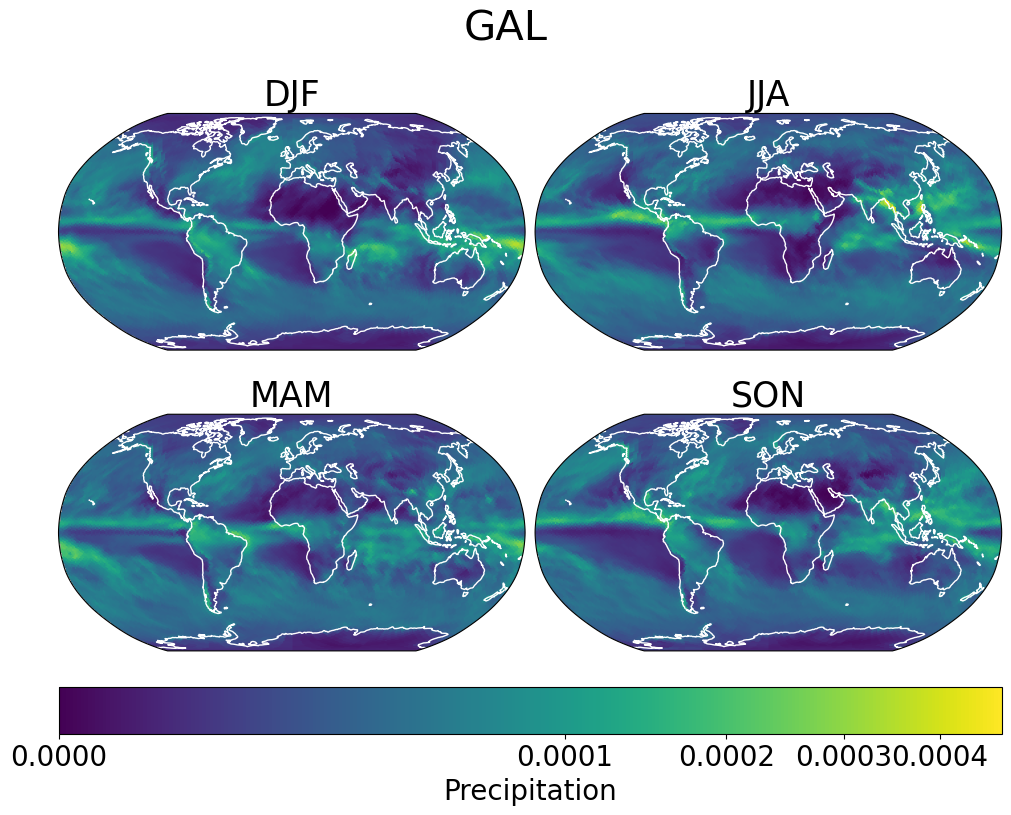

In [47]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import PowerNorm

# da = DataArray with dims ('season', 'cell')
# seasons: 'DJF', 'JJA', 'MAM', 'SON'

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.Robinson()},
    constrained_layout=True,
)

vmax = float(GAL_comp.max())

for ax, s in zip(axes.flat, GAL_comp.season.values):
    ax.set_global()
    plot = egh.healpix_show(
        GAL_comp.sel(season=s),
        ax=ax,
        cmap="viridis",
        norm=PowerNorm(gamma=0.4, vmin=0, vmax=vmax),
    )
    ax.set_title(str(s), fontsize=25)
    ax.coastlines(color="white")

cbar = fig.colorbar(plot, ax=axes, orientation="horizontal")
cbar.set_label("Precipitation", fontsize=20)
cbar.ax.tick_params(labelsize=20)
fig.suptitle("GAL", fontsize=30)
plt.show()

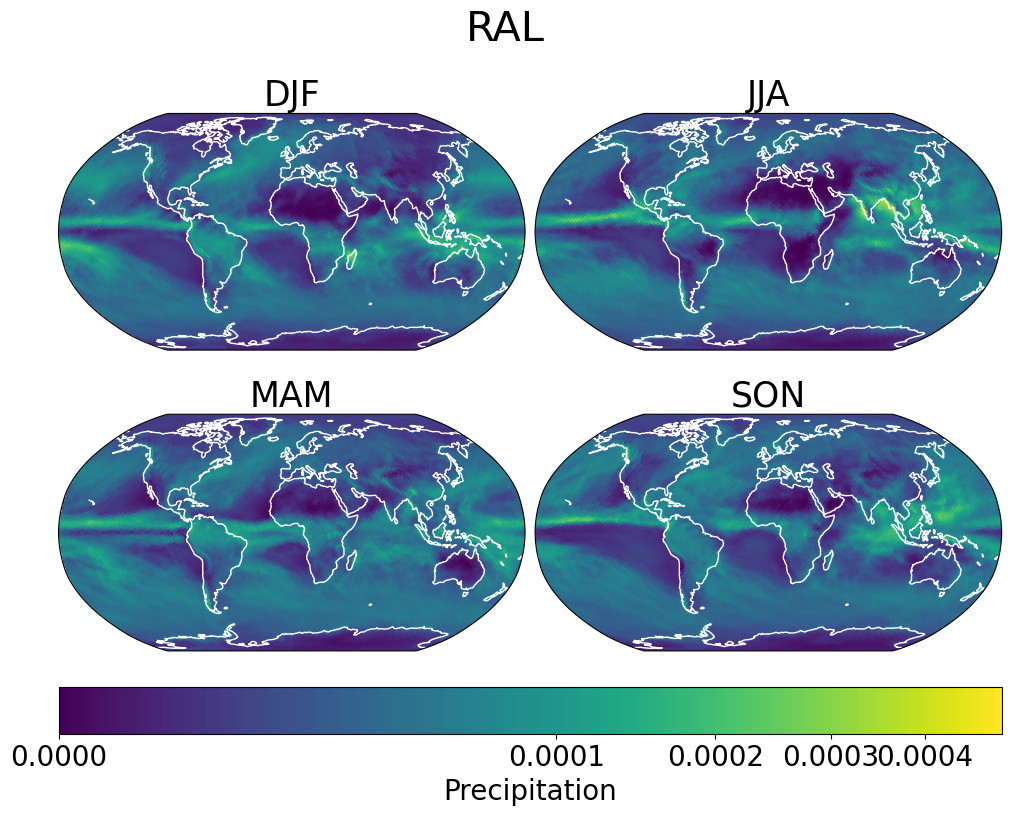

In [48]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import PowerNorm

# da = DataArray with dims ('season', 'cell')
# seasons: 'DJF', 'JJA', 'MAM', 'SON'

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.Robinson()},
    constrained_layout=True,
)

vmax = float(RAL_comp.max())

for ax, s in zip(axes.flat, RAL_comp.season.values):
    ax.set_global()
    plot = egh.healpix_show(
        RAL_comp.sel(season=s),
        ax=ax,
        cmap="viridis",
        norm=PowerNorm(gamma=0.4, vmin=0, vmax=vmax),
    )
    ax.set_title(str(s), fontsize=25)
    ax.coastlines(color="white")

cbar = fig.colorbar(plot, ax=axes, orientation="horizontal")
cbar.set_label("Precipitation", fontsize=20)
cbar.ax.tick_params(labelsize=20)
fig.suptitle("RAL", fontsize=30)
plt.show()

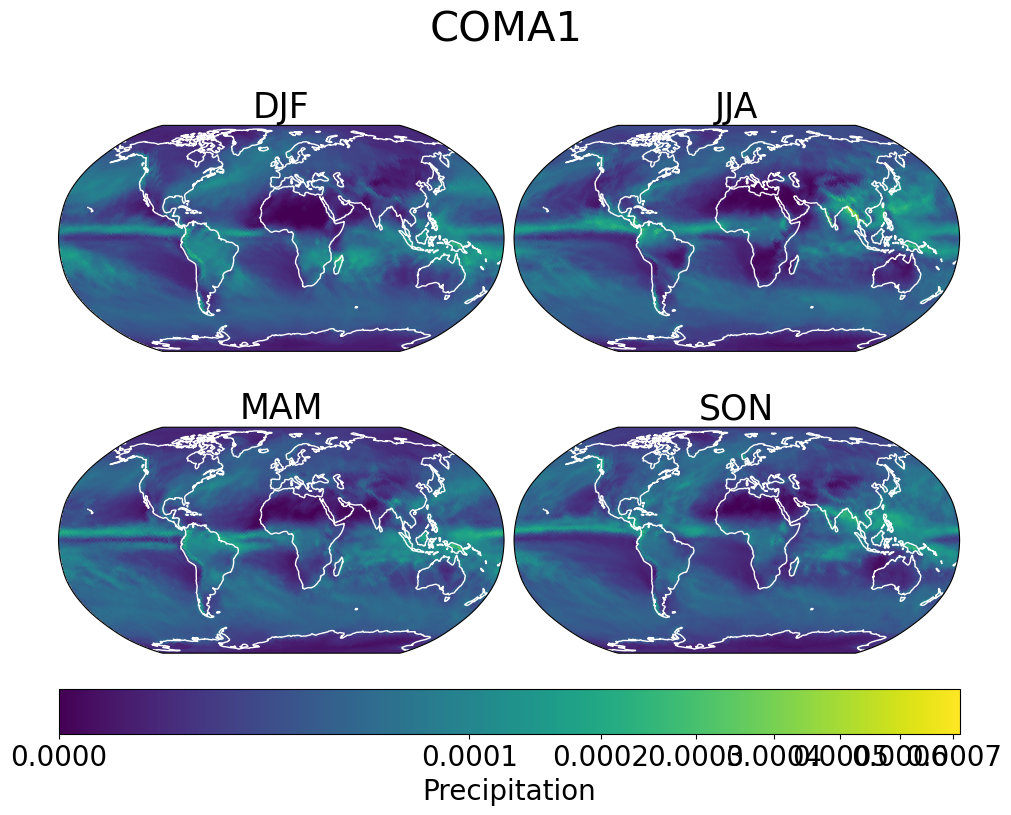

In [49]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import PowerNorm

# da = DataArray with dims ('season', 'cell')
# seasons: 'DJF', 'JJA', 'MAM', 'SON'

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.Robinson()},
    constrained_layout=True,
)

vmax = float(COMA1_comp.max())

for ax, s in zip(axes.flat, COMA1_comp.season.values):
    ax.set_global()
    plot = egh.healpix_show(
        COMA1_comp.sel(season=s),
        ax=ax,
        cmap="viridis",
        norm=PowerNorm(gamma=0.4, vmin=0, vmax=vmax),
    )
    ax.set_title(str(s), fontsize=25)
    ax.coastlines(color="white")

cbar = fig.colorbar(plot, ax=axes, orientation="horizontal")
cbar.set_label("Precipitation", fontsize=20)
cbar.ax.tick_params(labelsize=20)
fig.suptitle("COMA1", fontsize=30)
plt.show()

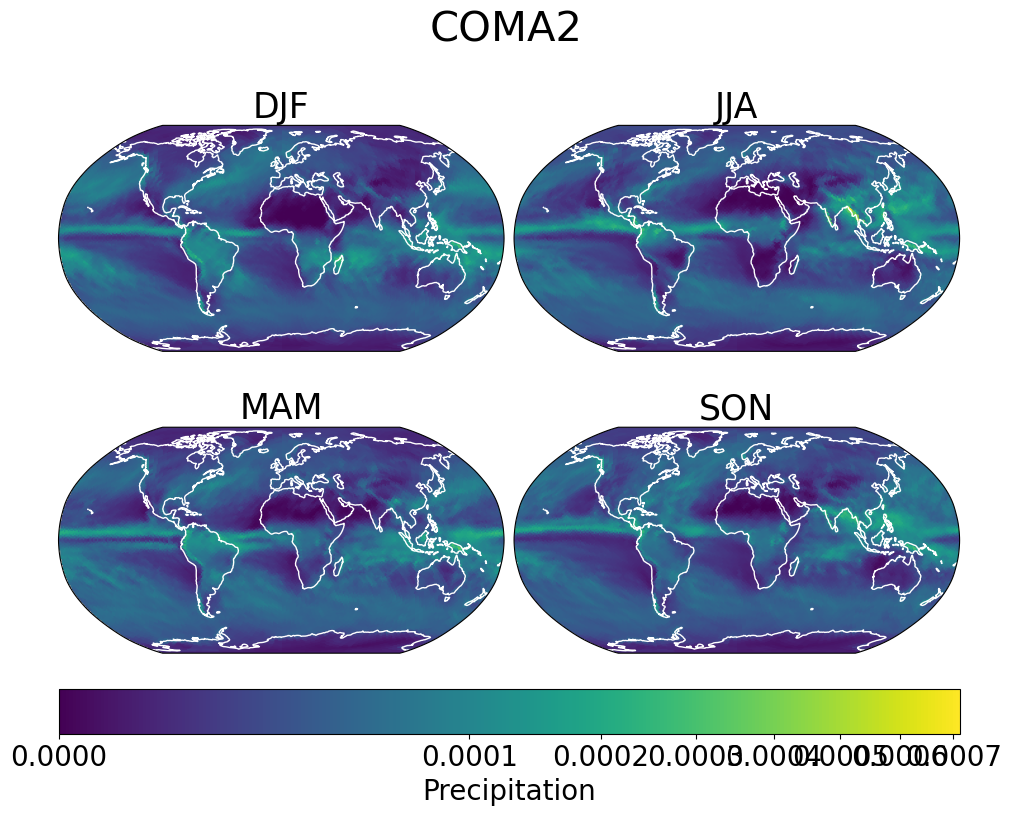

In [50]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import PowerNorm

# da = DataArray with dims ('season', 'cell')
# seasons: 'DJF', 'JJA', 'MAM', 'SON'

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.Robinson()},
    constrained_layout=True,
)

vmax = float(COMA2_comp.max())

for ax, s in zip(axes.flat, COMA2_comp.season.values):
    ax.set_global()
    plot = egh.healpix_show(
        COMA2_comp.sel(season=s),
        ax=ax,
        cmap="viridis",
        norm=PowerNorm(gamma=0.4, vmin=0, vmax=vmax),
    )
    ax.set_title(str(s), fontsize=25)
    ax.coastlines(color="white")

cbar = fig.colorbar(plot, ax=axes, orientation="horizontal")
cbar.set_label("Precipitation", fontsize=20)
cbar.ax.tick_params(labelsize=20)
fig.suptitle("COMA2", fontsize=30)
plt.show()

In [51]:
# Now plot differences between models

# 1a: GAL - RAL
GAL_min_RAL = (GAL_comp-RAL_comp).compute()

# 1b: GAL - COMA1
GAL_min_COMA1 = (GAL_comp-COMA1_comp).compute()

# 1c: GAL - COMA2
GAL_min_COMA2 = (GAL_comp-COMA2_comp).compute()


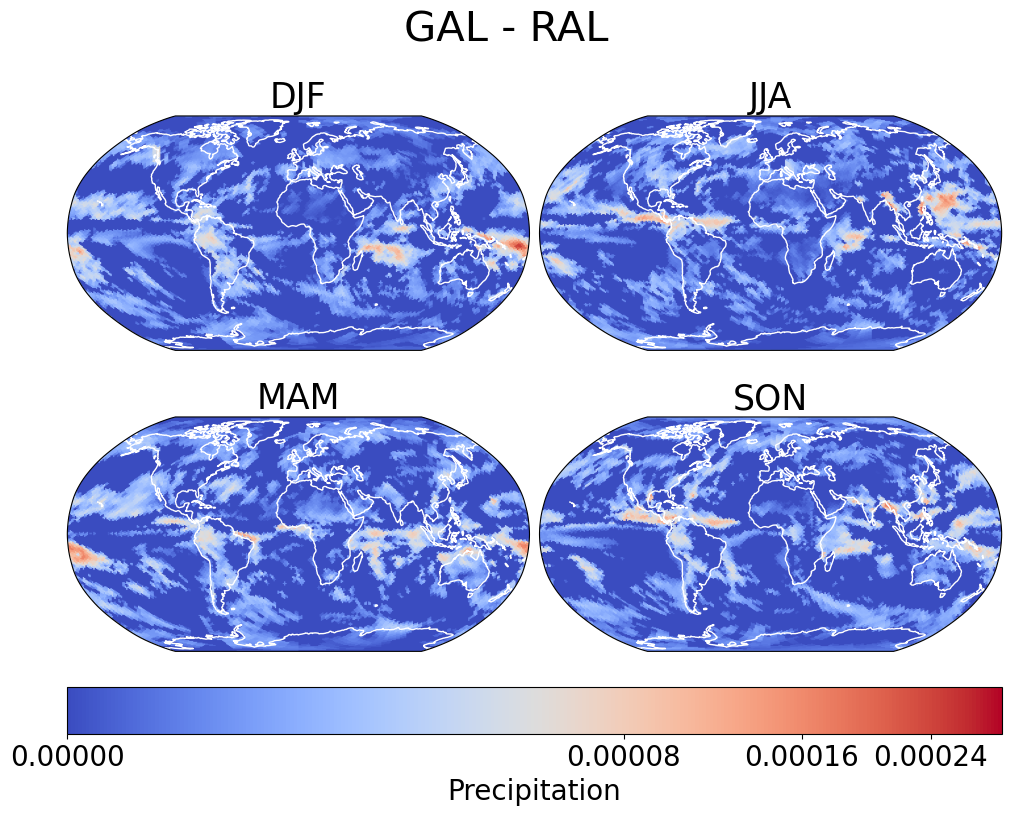

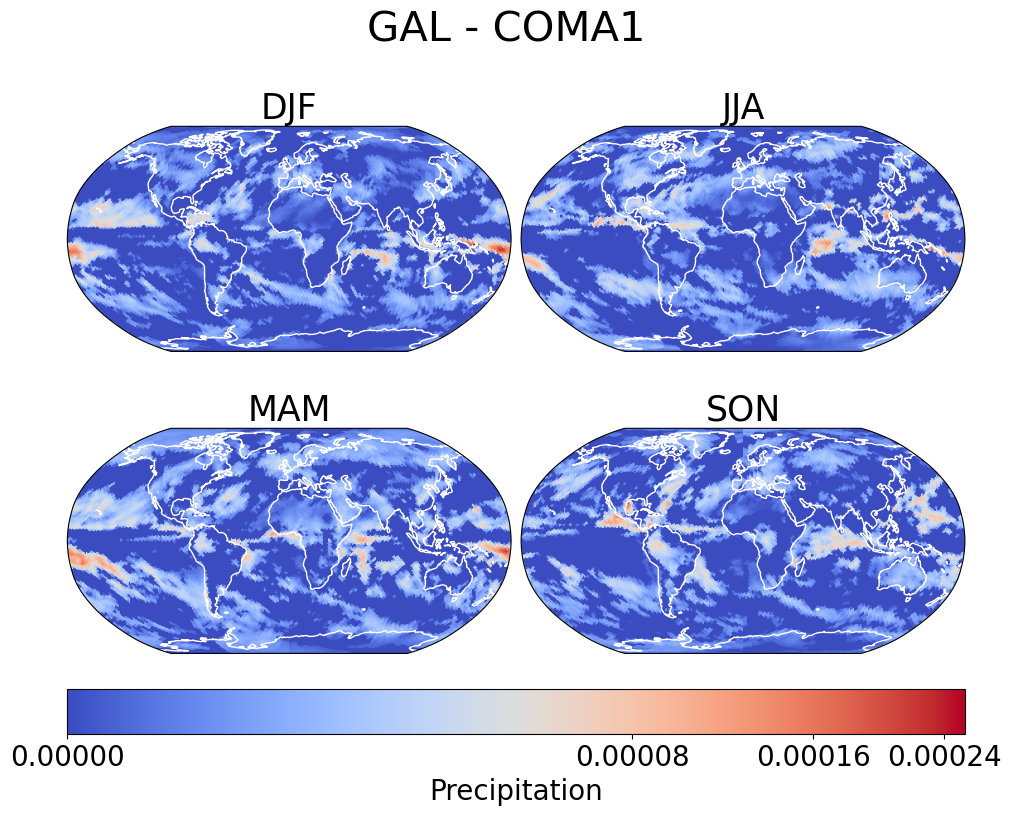

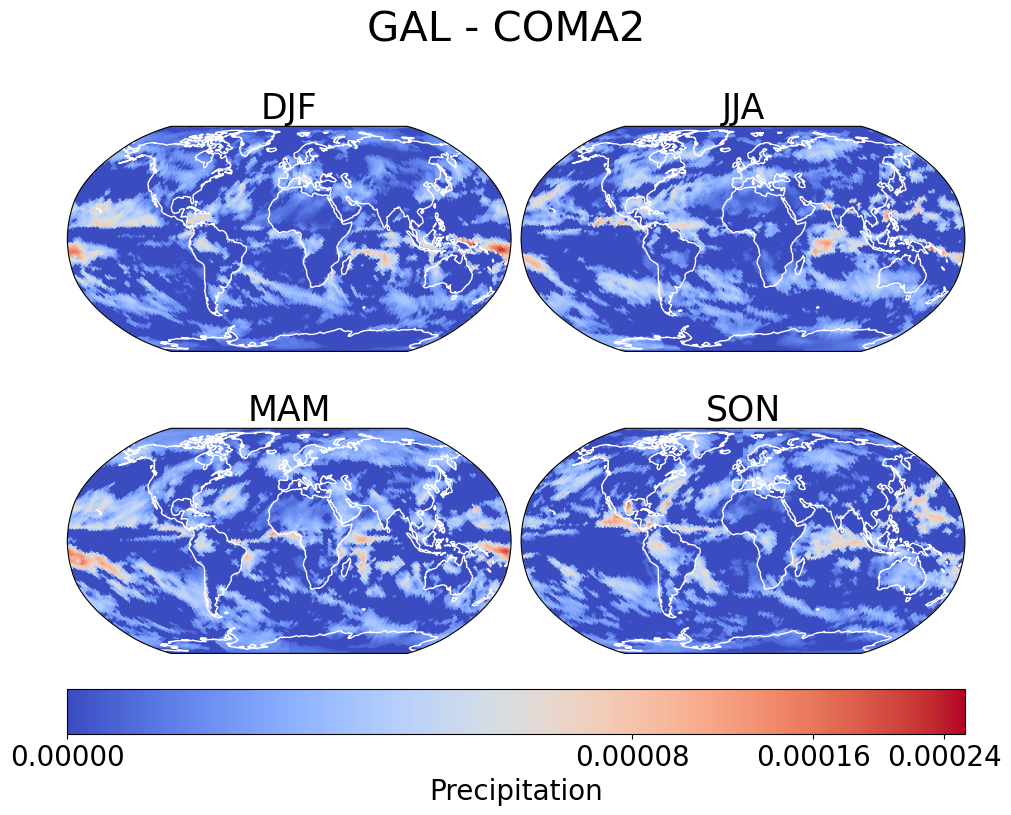

In [67]:
# GAL bias plots

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.Robinson()},
    constrained_layout=True,
)

vmax = float(GAL_min_RAL.max())

for ax, s in zip(axes.flat, GAL_min_RAL.season.values):
    ax.set_global()
    plot = egh.healpix_show(
        GAL_min_RAL.sel(season=s),
        ax=ax,
        cmap="coolwarm",
        norm=PowerNorm(gamma=0.4, vmin=0, vmax=vmax),
    )
    ax.set_title(str(s), fontsize=25)
    ax.coastlines(color="white")

cbar = fig.colorbar(plot, ax=axes, orientation="horizontal")
cbar.set_label("Precipitation", fontsize=20)
cbar.ax.tick_params(labelsize=20)
cbar.locator = ticker.MaxNLocator(nbins=4)
cbar.update_ticks()
fig.suptitle("GAL - RAL", fontsize=30)
plt.show()

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.Robinson()},
    constrained_layout=True,
)

vmax = float(GAL_min_COMA1.max())

for ax, s in zip(axes.flat, GAL_min_COMA1.season.values):
    ax.set_global()
    plot = egh.healpix_show(
        GAL_min_COMA1.sel(season=s),
        ax=ax,
        cmap="coolwarm",
        norm=PowerNorm(gamma=0.4, vmin=0, vmax=vmax),
    )
    ax.set_title(str(s), fontsize=25)
    ax.coastlines(color="white")

cbar = fig.colorbar(plot, ax=axes, orientation="horizontal")
cbar.set_label("Precipitation", fontsize=20)
cbar.ax.tick_params(labelsize=20)
cbar.locator = ticker.MaxNLocator(nbins=4)
cbar.update_ticks()
fig.suptitle("GAL - COMA1", fontsize=30)
plt.show()

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.Robinson()},
    constrained_layout=True,
)

vmax = float(GAL_min_COMA2.max())

for ax, s in zip(axes.flat, GAL_min_COMA2.season.values):
    ax.set_global()
    plot = egh.healpix_show(
        GAL_min_COMA2.sel(season=s),
        ax=ax,
        cmap="coolwarm",
        norm=PowerNorm(gamma=0.4, vmin=0, vmax=vmax),
    )
    ax.set_title(str(s), fontsize=25)
    ax.coastlines(color="white")

cbar = fig.colorbar(plot, ax=axes, orientation="horizontal")
cbar.set_label("Precipitation", fontsize=20)
cbar.locator = ticker.MaxNLocator(nbins=4)
cbar.update_ticks()
cbar.ax.tick_params(labelsize=20)
fig.suptitle("GAL - COMA2", fontsize=30)
plt.show()

In [68]:
# Now plot differences between models

# 2a: RAL - COMA1
RAL_min_COMA1 = (RAL_comp-COMA1_comp).compute()

# 2b: RAL - COMA2
RAL_min_COMA2 = (RAL_comp-COMA2_comp).compute()

# 3a: COMA1 - COMA2
COMA1_min_COMA2 = (COMA1_comp-COMA2_comp).compute()

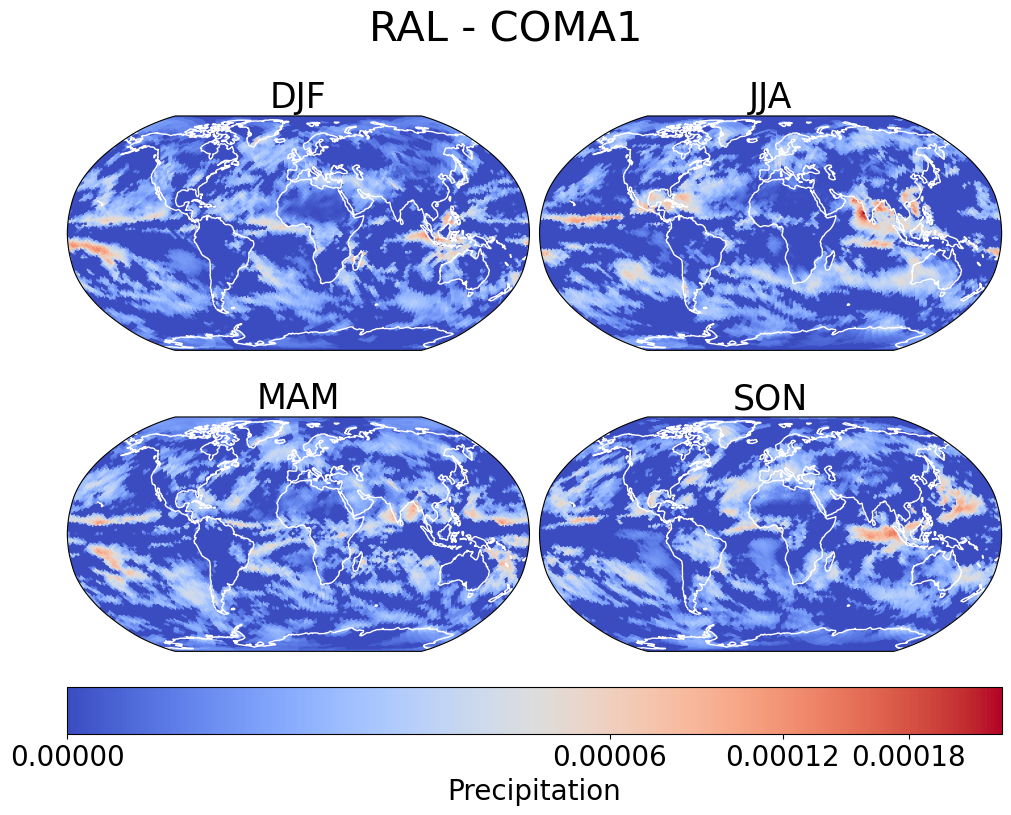

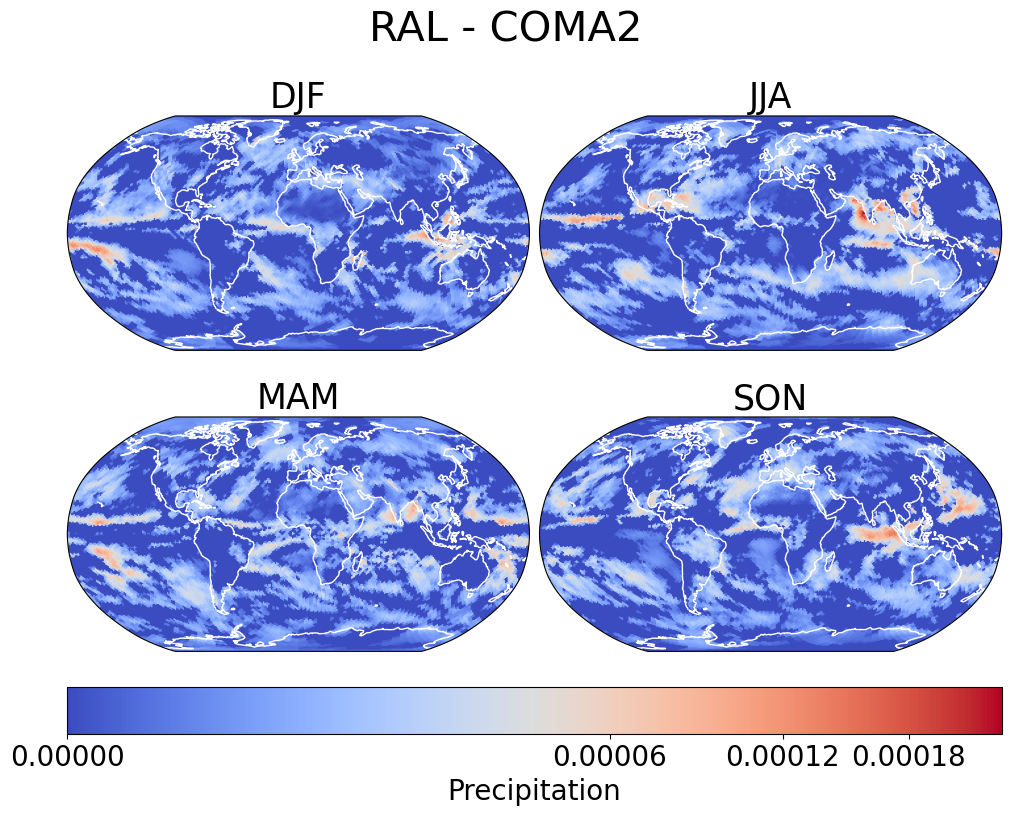

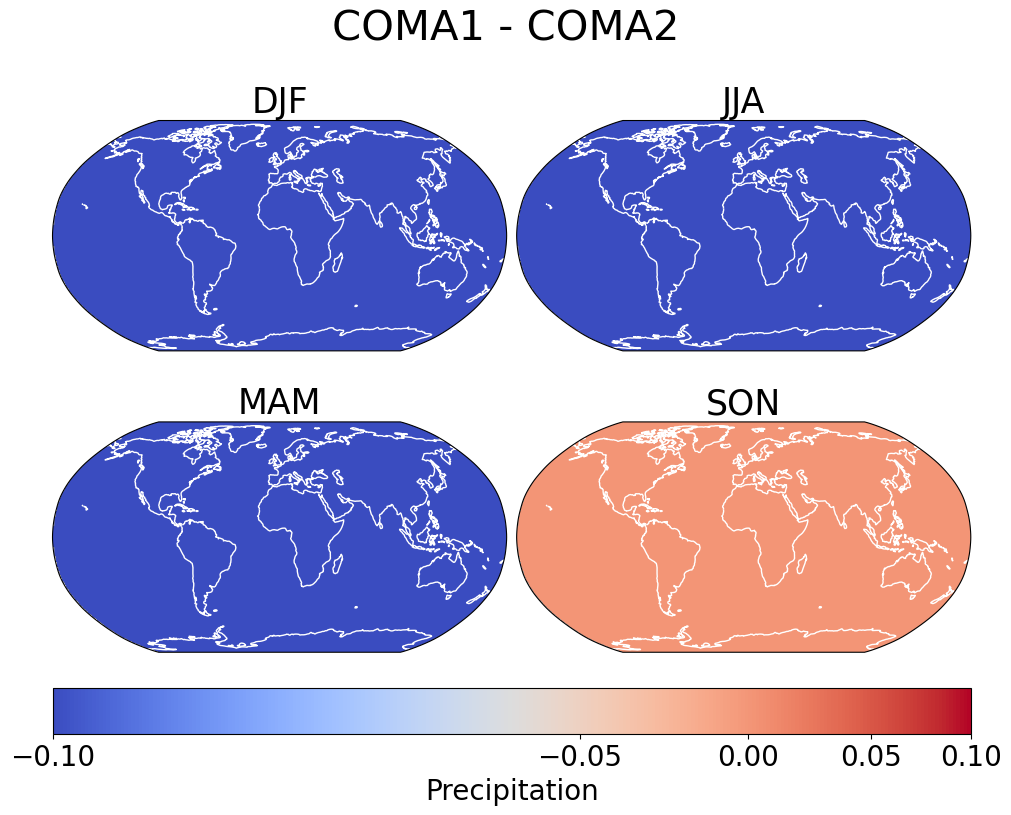

In [66]:
# RAL and COMA bias plots

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.Robinson()},
    constrained_layout=True,
)

vmax = float(RAL_min_COMA1.max())

for ax, s in zip(axes.flat, RAL_min_COMA1.season.values):
    ax.set_global()
    plot = egh.healpix_show(
        RAL_min_COMA1.sel(season=s),
        ax=ax,
        cmap="coolwarm",
        norm=PowerNorm(gamma=0.4, vmin=0, vmax=vmax),
    )
    ax.set_title(str(s), fontsize=25)
    ax.coastlines(color="white")

cbar = fig.colorbar(plot, ax=axes, orientation="horizontal")
cbar.set_label("Precipitation", fontsize=20)
cbar.ax.tick_params(labelsize=20)
cbar.locator = ticker.MaxNLocator(nbins=4)
cbar.update_ticks()
fig.suptitle("RAL - COMA1", fontsize=30)
plt.show()

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.Robinson()},
    constrained_layout=True,
)

vmax = float(RAL_min_COMA2.max())

for ax, s in zip(axes.flat, RAL_min_COMA2.season.values):
    ax.set_global()
    plot = egh.healpix_show(
        RAL_min_COMA2.sel(season=s),
        ax=ax,
        cmap="coolwarm",
        norm=PowerNorm(gamma=0.4, vmin=0, vmax=vmax),
    )
    ax.set_title(str(s), fontsize=25)
    ax.coastlines(color="white")

cbar = fig.colorbar(plot, ax=axes, orientation="horizontal")
cbar.set_label("Precipitation", fontsize=20)
cbar.ax.tick_params(labelsize=20)
cbar.locator = ticker.MaxNLocator(nbins=4)
cbar.update_ticks()
fig.suptitle("RAL - COMA2", fontsize=30)
plt.show()

import matplotlib.ticker as ticker

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.Robinson()},
    constrained_layout=True,
)

vmax = float(COMA1_min_COMA2.max())

for ax, s in zip(axes.flat, COMA1_min_COMA2.season.values):
    ax.set_global()
    plot = egh.healpix_show(
        COMA1_min_COMA2.sel(season=s),
        ax=ax,
        cmap="coolwarm",
        norm=PowerNorm(gamma=0.4, vmin=0, vmax=vmax),
    )
    ax.set_title(str(s), fontsize=25)
    ax.coastlines(color="white")

cbar = fig.colorbar(plot, ax=axes, orientation="horizontal")
cbar.set_label("Precipitation", fontsize=20)
cbar.ax.tick_params(labelsize=20)

# formatter = ticker.ScalarFormatter(useMathText=True)
cbar.locator = ticker.MaxNLocator(nbins=4)
# cbar.formatter = formatter
cbar.update_ticks()

fig.suptitle("COMA1 - COMA2", fontsize=30)
plt.show()

In [1]:
# Get observational data
ds_imerg = cat['IR_IMERG'](zoom=9).to_dask()
print(ds_imerg)

NameError: name 'cat' is not defined

In [96]:
GAL_min_IMERG = GAL_m - imerg 
print(GAL_min_IMERG)

<xarray.Dataset> Size: 1TB
Dimensions:        (season: 4, lon: 3600, lat: 1800, cell: 12288)
Coordinates:
  * season         (season) object 32B 'DJF' 'MAM' 'JJA' 'SON'
  * lon            (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.8 179.9
  * lat            (lat) float32 7kB -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * cell           (cell) int64 98kB 0 1 2 3 4 ... 12283 12284 12285 12286 12287
    crs            int64 8B 0
Data variables:
    precipitation  (season, cell, lon, lat) float32 1TB dask.array<chunksize=(1, 12288, 3600, 1800), meta=np.ndarray>
Attributes:
    standard_name:  precipitation_flux
    units:          kg m-2 s-1
    source:         Data from Met Office Unified Model
    um_version:     13.5
    STASH:          [1, 5, 205]
    cell_methods:   time: mean (interval: 1 hour)
    long_name:      precipitation_flux
    variable_id:    pr
    UM_vars:        ['convective_rainfall_flux', 'convective_snowfall_flux', ...
    notes:          Combined rain and 